In this project we will complete the following steps and answer the following questions:
1) Load your datasets and perform some simple exploratory data analysis.
2) Create a new column to represent the like-dislike ratio (likes divided by dislikes) for the videos in each dataset.
3) What is the average like-dislike ratio for all of the videos? (average number of likes per video divided by the average number of dislikes per video).
4) Perform data manipulation to find the average number of likes per video for the US and GB in the year 2018.
5) **Business report:** Your client hypothesizes that the most polarizing videos get shared the most. Analyze the data to determine whether your client is correct, and what other metrics should be investigated. Be sure to define any terms or cutoffs you make in the data. Present your findings in a short report for the client to review.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import json
import seaborn as sns
# loading the first dataframe and examining
df_US = pd.read_csv('USvideos.csv')
# loading category id map
with open('US_category_id.json') as f:
    category_data = json.load(f)
print(df_US.columns)
print(df_US.info())
print(df_US.head())

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   video_id                40949 non-null  str  
 1   trending_date           40949 non-null  str  
 2   title                   40949 non-null  str  
 3   channel_title           40949 non-null  str  
 4   category_id             40949 non-null  int64
 5   publish_time            40949 non-null  str  
 6   tags                    40949 non-null  str  
 7   views                   40949 non-null  int64
 8   likes                   40949 non-null  int64
 9   dislikes                40949 non-null  int64
 

In [51]:
df_GB = pd.read_csv('GBvideos.csv')
print(df_GB.head())
print(df_US.category_id.unique())

      video_id trending_date  \
0  Jw1Y-zhQURU      17.14.11   
1  3s1rvMFUweQ      17.14.11   
2  n1WpP7iowLc      17.14.11   
3  PUTEiSjKwJU      17.14.11   
4  rHwDegptbI4      17.14.11   

                                               title  \
0      John Lewis Christmas Ad 2017 - #MozTheMonster   
1          Taylor Swift: …Ready for It? (Live) - SNL   
2         Eminem - Walk On Water (Audio) ft. Beyoncé   
3  Goals from Salford City vs Class of 92 and Fri...   
4  Dashcam captures truck's near miss with child ...   

                channel_title  category_id              publish_time  \
0                  John Lewis           26  2017-11-10T07:38:29.000Z   
1         Saturday Night Live           24  2017-11-12T06:24:44.000Z   
2                  EminemVEVO           10  2017-11-10T17:00:03.000Z   
3  Salford City Football Club           17  2017-11-13T02:30:38.000Z   
4            Cute Girl Videos           25  2017-11-13T01:45:13.000Z   

                                     

In [52]:
# two columns should be datetime but are listed as objects: trending_date, publish_time
# converting columns to datetime
df_US.publish_time = pd.to_datetime(df_US.publish_time)
df_GB.publish_time = pd.to_datetime(df_GB.publish_time)

df_US.trending_date = pd.to_datetime(df_US.trending_date, format='%y.%d.%m') # date format is unique
df_GB.trending_date = pd.to_datetime(df_GB.trending_date, format='%y.%d.%m')

print(df_US.publish_time.head())
print(df_GB.publish_time.head())

print(df_US.info())
print(df_GB.info())

0   2017-11-13 17:13:01+00:00
1   2017-11-13 07:30:00+00:00
2   2017-11-12 19:05:24+00:00
3   2017-11-13 11:00:04+00:00
4   2017-11-12 18:01:41+00:00
Name: publish_time, dtype: datetime64[us, UTC]
0   2017-11-10 07:38:29+00:00
1   2017-11-12 06:24:44+00:00
2   2017-11-10 17:00:03+00:00
3   2017-11-13 02:30:38+00:00
4   2017-11-13 01:45:13+00:00
Name: publish_time, dtype: datetime64[us, UTC]
<class 'pandas.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                40949 non-null  str                
 1   trending_date           40949 non-null  datetime64[us]     
 2   title                   40949 non-null  str                
 3   channel_title           40949 non-null  str                
 4   category_id             40949 non-null  int64              
 5   publish_time            40949 non-null  datetime

In [53]:
# category_id should be in category format
df_US.category_id = df_US.category_id.astype('category')
df_GB.category_id = df_GB.category_id.astype('category')

print('Unique values count:')
print(df_US.category_id.nunique())
print(df_GB.category_id.nunique())
print(df_US.category_id.unique())
print(df_GB.category_id.unique())

Unique values count:
16
16
[22, 24, 23, 28, 1, ..., 2, 19, 20, 29, 43]
Length: 16
Categories (16, int64): [1, 2, 10, 15, ..., 27, 28, 29, 43]
[26, 24, 10, 17, 25, ..., 20, 2, 19, 29, 43]
Length: 16
Categories (16, int64): [1, 2, 10, 15, ..., 27, 28, 29, 43]


In [54]:
# mapping category_id to our category_data
category_map = {
    int(item['id']) : item['snippet']['title']
    for item in category_data['items']
}
print(category_map)

{1: 'Film & Animation', 2: 'Autos & Vehicles', 10: 'Music', 15: 'Pets & Animals', 17: 'Sports', 18: 'Short Movies', 19: 'Travel & Events', 20: 'Gaming', 21: 'Videoblogging', 22: 'People & Blogs', 23: 'Comedy', 24: 'Entertainment', 25: 'News & Politics', 26: 'Howto & Style', 27: 'Education', 28: 'Science & Technology', 29: 'Nonprofits & Activism', 30: 'Movies', 31: 'Anime/Animation', 32: 'Action/Adventure', 33: 'Classics', 34: 'Comedy', 35: 'Documentary', 36: 'Drama', 37: 'Family', 38: 'Foreign', 39: 'Horror', 40: 'Sci-Fi/Fantasy', 41: 'Thriller', 42: 'Shorts', 43: 'Shows', 44: 'Trailers'}


In [55]:
print(df_US.trending_date.drop_duplicates().head(30)) # need a few more rows to validate date format and drop_duplicates helps display more unique dates
print(df_GB.trending_date.drop_duplicates().head(30))

0      2017-11-14
200    2017-11-15
400    2017-11-16
600    2017-11-17
800    2017-11-18
1000   2017-11-19
1200   2017-11-20
1400   2017-11-21
1600   2017-11-22
1800   2017-11-23
2000   2017-11-24
2200   2017-11-25
2400   2017-11-26
2600   2017-11-27
2800   2017-11-28
3000   2017-11-29
3200   2017-11-30
3400   2017-12-01
3600   2017-12-02
3800   2017-12-03
4000   2017-12-04
4200   2017-12-05
4400   2017-12-06
4600   2017-12-07
4800   2017-12-08
5000   2017-12-09
5200   2017-12-10
5400   2017-12-11
5600   2017-12-12
5800   2017-12-13
Name: trending_date, dtype: datetime64[us]
0      2017-11-14
200    2017-11-15
399    2017-11-16
598    2017-11-17
798    2017-11-18
998    2017-11-19
1198   2017-11-20
1398   2017-11-21
1598   2017-11-22
1798   2017-11-23
1998   2017-11-24
2198   2017-11-25
2398   2017-11-26
2598   2017-11-27
2798   2017-11-28
2998   2017-11-29
3198   2017-11-30
3398   2017-12-01
3596   2017-12-02
3795   2017-12-03
3994   2017-12-04
4194   2017-12-05
4394   2017-12-06
459

In [56]:
# datatypes are corrrected and datetime format looks consistent
# quantifying the missing values in description column
print(df_US.description.isnull().sum())
print(df_GB.description.isnull().sum())

570
612


Out of 40949 entries, 570 descriptions are left missing in the US data set. Out of 38916, 612 are missing from the Great Britian dataset. I'll keep the missing entries in to check for confounding variables, but we are examining views and like to dislike ratios so it's likely not important.

In [57]:
print(df_US.duplicated().sum())
print(df_US.video_id.nunique())
print(df_GB.duplicated().sum())
print(df_GB.video_id.nunique())
print(df_US.category_id.nunique())
print(df_GB.category_id.nunique())

48
6351
171
3272
16
16


A quick glance at the unique number of rows and we can see this appears to be daily video metrics rather than unique video data. The question posed, "What is the average like-dislike ratio for all of the videos," implies unique videos not video-day observations. The data frames will have to be aggregated by video id. Since videos appear on multiple trending days, I will aggregate to one row per video using peak values.

In [58]:
df_US_video = (
    df_US
    .groupby('video_id')
    .agg({
        'views': 'max',
        'likes': 'max',
        'dislikes': 'max',
        'comment_count': 'max',
        'publish_time': 'first', # publish time over trending time used to find "the average number of likes per video for the US and GB in the year 2018"
        'category_id': 'first'
    })
    .reset_index()
)
df_GB_video = (
    df_GB
    .groupby('video_id')
    .agg({
        'views': 'max',
        'likes': 'max',
        'dislikes': 'max',
        'comment_count': 'max',
        'publish_time': 'first',
        'category_id': 'first'
    })
    .reset_index()
)

print(df_US_video.head())
print(df_GB_video.head())

      video_id    views  likes  dislikes  comment_count  \
0  -0CMnp02rNY   800359   9773       332            423   
1  -0NYY8cqdiQ   563746   4429        54             94   
2  -1Hm41N0dUs  2058516  41248       580           1490   
3  -1yT-K3c6YI   231341   7734       212            846   
4  -2RVw2_QyxQ    71089    460        27             23   

               publish_time category_id  
0 2018-06-04 13:00:00+00:00          24  
1 2018-01-29 14:00:39+00:00          24  
2 2018-04-27 07:30:02+00:00          23  
3 2017-11-28 18:30:43+00:00          22  
4 2017-11-12 02:39:01+00:00          27  
      video_id    views   likes  dislikes  comment_count  \
0  --uXQQ0h-yQ    28725     253         3             12   
1  -3VBPAZPTQI   404690   16002       306            858   
2  -43MBOJnVks  1758599   16188       832           2182   
3  -5WBCrazSfg   345486    6810       121            688   
4  -5aaJJQFvOg  1770509  163869      2704           7269   

               publish_time cate

In [59]:
# the dataframes have been aggregated
# adding likes to dislike ratio column
# checking for zero dislikes as they will impact calculations
df_US_zero_dislikes = df_US_video[df_US_video['dislikes'] == 0]
print(df_US_zero_dislikes.count())
df_GB_zero_dislikes = df_GB_video[df_GB_video['dislikes'] == 0]
print(df_GB_zero_dislikes.count())

video_id         93
views            93
likes            93
dislikes         93
comment_count    93
publish_time     93
category_id      93
dtype: int64
video_id         23
views            23
likes            23
dislikes         23
comment_count    23
publish_time     23
category_id      23
dtype: int64


In [60]:
# 93 and 23 zero dislikes entries for both dataframes
# assigning NaN to zero dislikes removes 116 entries, which affects results very little
# they would be left skewing outliers that do not meaningfully add to our analysis at the moment
df_US_video['likes_to_dislikes'] = np.where(
    df_US_video['dislikes'] > 0,
    df_US_video['likes'] / df_US_video['dislikes'],
    np.nan
)
print(df_US_video.head())
print(df_US_video.isnull().sum())
df_GB_video['likes_to_dislikes'] = np.where(
    df_GB_video['dislikes'] > 0,
    df_GB_video['likes'] / df_GB_video['dislikes'],
    np.nan
)
print(df_GB_video.head())
print(df_GB_video.isnull().sum())

      video_id    views  likes  dislikes  comment_count  \
0  -0CMnp02rNY   800359   9773       332            423   
1  -0NYY8cqdiQ   563746   4429        54             94   
2  -1Hm41N0dUs  2058516  41248       580           1490   
3  -1yT-K3c6YI   231341   7734       212            846   
4  -2RVw2_QyxQ    71089    460        27             23   

               publish_time category_id  likes_to_dislikes  
0 2018-06-04 13:00:00+00:00          24          29.436747  
1 2018-01-29 14:00:39+00:00          24          82.018519  
2 2018-04-27 07:30:02+00:00          23          71.117241  
3 2017-11-28 18:30:43+00:00          22          36.481132  
4 2017-11-12 02:39:01+00:00          27          17.037037  
video_id              0
views                 0
likes                 0
dislikes              0
comment_count         0
publish_time          0
category_id           0
likes_to_dislikes    93
dtype: int64
      video_id    views   likes  dislikes  comment_count  \
0  --uXQQ0h-yQ

In [61]:
# now that the dataframes are aggregated, analyzing again
print(df_US_video.describe())
print(df_GB_video.describe())

              views         likes      dislikes  comment_count  \
count  6.351000e+03  6.351000e+03  6.351000e+03   6.351000e+03   
mean   1.963852e+06  5.563610e+04  3.070096e+03   6.517249e+03   
std    7.061186e+06  1.938801e+05  3.198844e+04   3.391880e+04   
min    5.590000e+02  0.000000e+00  0.000000e+00   0.000000e+00   
25%    1.591565e+05  2.781500e+03  1.270000e+02   3.865000e+02   
50%    5.181070e+05  1.190600e+04  4.450000e+02   1.298000e+03   
75%    1.474750e+06  3.842850e+04  1.511000e+03   4.158500e+03   
max    2.252119e+08  5.613827e+06  1.674420e+06   1.361580e+06   

       likes_to_dislikes  
count        6258.000000  
mean           41.713784  
std            51.790658  
min             0.000000  
25%            11.676730  
50%            26.836800  
75%            53.771535  
max          1493.750000  
              views         likes      dislikes  comment_count  \
count  3.272000e+03  3.272000e+03  3.272000e+03   3.272000e+03   
mean   4.814560e+06  9.991873e

The newly created likes to dislikes column is working as expected but the max is 840.75 and 1493.75. The method of tracking likes to dislikes as a ratio is unstable at extremely low dislike values making analysis harder. In the future, I would suggest using dislikes as a share of dislikes and likes together. This would bound the values between 0 and 1. But a ratio is what was in the instructions so I will continue.
Many right skewed metrics exhist. For instance, US views average is 1.96M but the median is 518,107. This pattern happens across the board which indicates a small number of videos are driving a majority of the interactions.

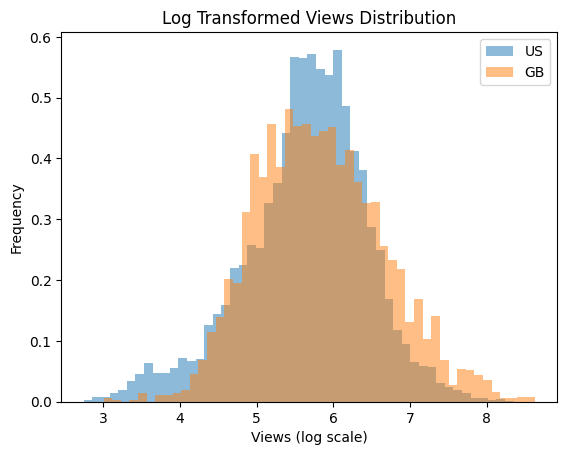

In [79]:
# histogram function
def histogram(x, xlabel, title):
    log_x_us = np.log10(df_US_video[x] + 1) # log10 will continue to be used for our heavily skewed dataset
    log_x_gb = np.log10(df_GB_video[x] + 1) # +1 to avoid issues with 0
    plt.hist(log_x_us, bins=50, alpha=0.5, density=True, label='US') # overlaying both plots at 50% transparency
    plt.hist(log_x_gb, bins=50, alpha=0.5, density=True, label='GB') # both countries overlaying scaled to fit as GB is half of US dataset
    plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.title(title)
    plt.show()

histogram('views', 'Views (log scale)', 'Log Transformed Views Distribution')

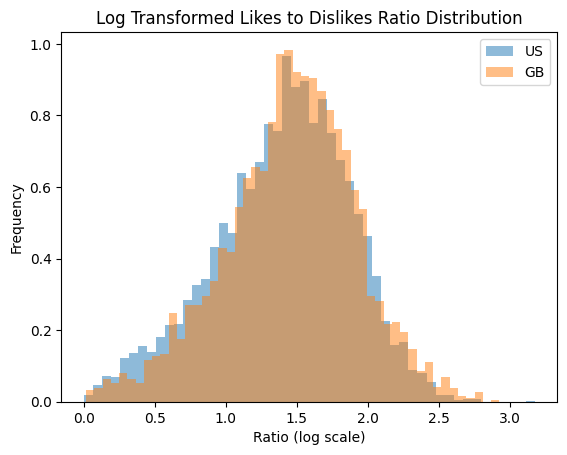

In [80]:
# Great Britain has an even tighter spread than the US but still shares the same mode of 1 million. 
# This suggests while viral videos are similar in viewership in both countries, in Great Britain those viewerships are much more dramatic
# histogram of ratio
histogram('likes_to_dislikes', 'Ratio (log scale)', 'Log Transformed Likes to Dislikes Ratio Distribution')

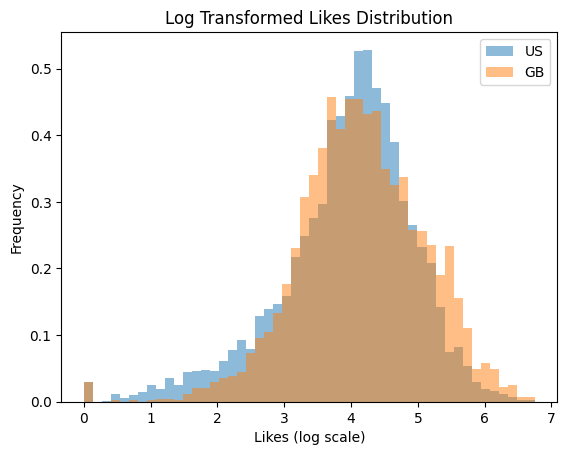

video_id             6351
views                6351
likes                6351
dislikes             6351
comment_count        6351
publish_time         6351
category_id          6351
likes_to_dislikes    6258
dtype: int64
video_id             3272
views                3272
likes                3272
dislikes             3272
comment_count        3272
publish_time         3272
category_id          3272
likes_to_dislikes    3249
dtype: int64


In [81]:
# normal log dsitrobution in like to dislike ratio for both countries
# 10^1.5 is about 31.5 likes per dislike
# a steep drop off at 100 likes per dislike and 10 likes per dislike, very polarizing videos are actually rare
# histogram of likes
histogram('likes', 'Likes (log scale)', 'Log Transformed Likes Distribution')

print(df_US_video.count()) # validating the size of each dataset
print(df_GB_video.count())

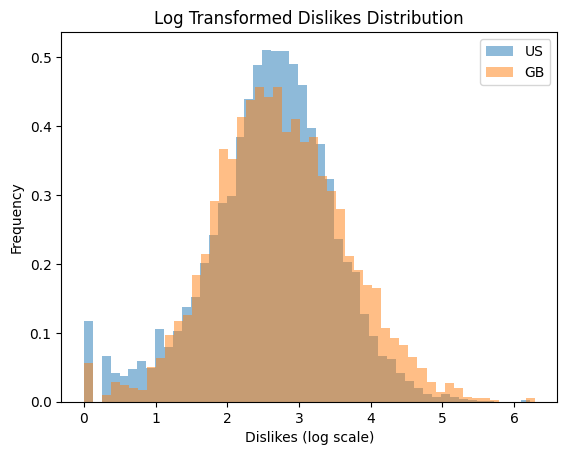

In [82]:
# histogram spread is fairly symetrical and both countries look the same
# Because density is set True, we avoid the issue of the US dataset being larger
# histogram of dislikes
histogram('dislikes', 'Dislikes (log scale)', 'Log Transformed Dislikes Distribution')

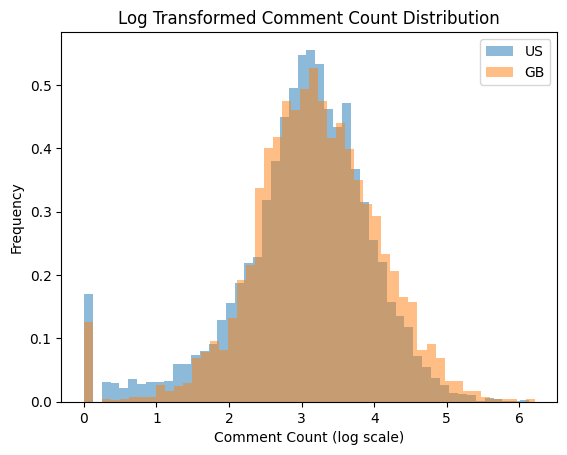

In [83]:
# comment count histogram
histogram('comment_count', 'Comment Count (log scale)', 'Log Transformed Comment Count Distribution')

In [67]:
# histograms all look fairly symetrical in log scale and are similar between countries
# answering the question, "whats the average ratio for all videos?"
all_df_video = pd.concat([df_US_video.assign(country='US'),
                          df_GB_video.assign(country='GB')])
mean_ratio = (
    all_df_video['likes'].mean() /
    all_df_video['dislikes'].mean()
)
print(f'Average ratio of likes to dislikes: {mean_ratio:.2f}') # rounded 2 decimals
print(all_df_video.head())

Average ratio of likes to dislikes: 17.48
      video_id    views  likes  dislikes  comment_count  \
0  -0CMnp02rNY   800359   9773       332            423   
1  -0NYY8cqdiQ   563746   4429        54             94   
2  -1Hm41N0dUs  2058516  41248       580           1490   
3  -1yT-K3c6YI   231341   7734       212            846   
4  -2RVw2_QyxQ    71089    460        27             23   

               publish_time category_id  likes_to_dislikes country  
0 2018-06-04 13:00:00+00:00          24          29.436747      US  
1 2018-01-29 14:00:39+00:00          24          82.018519      US  
2 2018-04-27 07:30:02+00:00          23          71.117241      US  
3 2017-11-28 18:30:43+00:00          22          36.481132      US  
4 2017-11-12 02:39:01+00:00          27          17.037037      US  


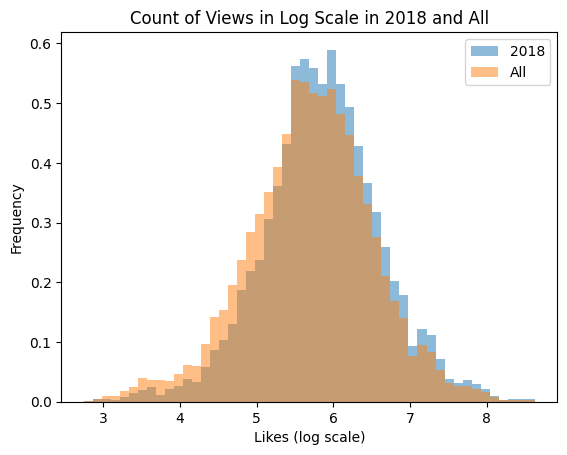

Average views in 2018: 3656840.82
Median views in 2018: 711676.0


In [68]:
# the average like-dislike ratio for all of the videos is 17.48 likes to dislikes
# finding the average number of likes per video for the US and GB in the year 2018
df_2018 = all_df_video[all_df_video['publish_time'].dt.year == 2018]
plt.hist(np.log10(df_2018.views + 1), bins=50, alpha=0.5, density=True, label='2018')
plt.hist(np.log10(all_df_video.views + 1), bins=50, alpha=0.5, density=True, label='All')
plt.xlabel('Likes (log scale)')
plt.ylabel('Frequency')
plt.title('Count of Views in Log Scale in 2018 and All')
plt.legend()
plt.show()
average_2018 = np.round(df_2018.views.mean(), 2)
print(f'Average views in 2018: {average_2018}')
median_2018 = np.round(df_2018.views.median(), 2)
print(f'Median views in 2018: {median_2018}')

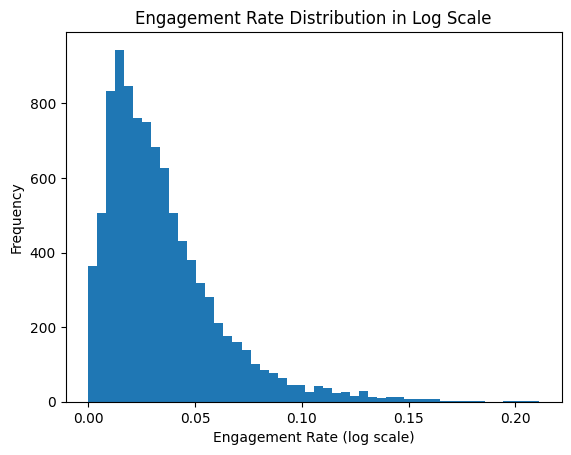

In [69]:
# Average likes in 2018 is approximately 3656840.82
# are the most polarizing videos getting shared the most?
# creating engagement rate column
all_df_video['engagement_rate'] = (
    (all_df_video['likes'] + all_df_video['dislikes'] + all_df_video['comment_count']) / # all likes, dislikes, and comments per view as "engegment rate"
    all_df_video['views']
)
plt.hist(np.log1p(all_df_video['engagement_rate']), bins=50) #log1p used to handle the right-skewed distribution; 
# note that views = 0 would cause division by zero in the engagement rate formula and should be filtered
plt.xlabel('Engagement Rate (log scale)')
plt.ylabel('Frequency')
plt.title('Engagement Rate Distribution in Log Scale')
plt.show()

During analysis I discovered an error in the engagement metric definition. After correcting the formula to (likes + dislikes + comments) / views, the distribution changed from symmetric to strongly right-skewed, which is more typical of engagement dynamics. Only a small number of videos capture a disproportionate level of interaction.

                      views     likes  dislikes  comment_count  \
views              1.000000  0.872395  0.869085       0.779613   
likes              0.872395  1.000000  0.842857       0.850138   
dislikes           0.869085  0.842857  1.000000       0.817024   
comment_count      0.779613  0.850138  0.817024       1.000000   
likes_to_dislikes  0.100005  0.369288 -0.215111       0.135044   
engagement_rate   -0.006150  0.356118  0.118121       0.336707   

                   likes_to_dislikes  engagement_rate  
views                       0.100005        -0.006150  
likes                       0.369288         0.356118  
dislikes                   -0.215111         0.118121  
comment_count               0.135044         0.336707  
likes_to_dislikes           1.000000         0.476457  
engagement_rate             0.476457         1.000000  


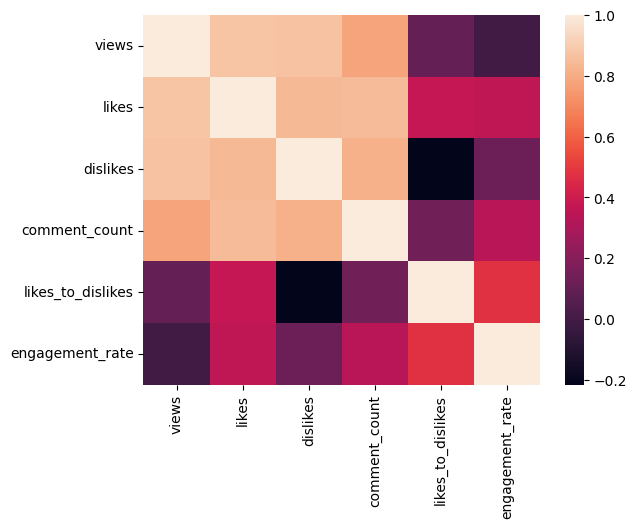

In [70]:
# creating a crosstable of variables
corr_matrix_all = all_df_video[[
    'views',
    'likes',
    'dislikes',
    'comment_count',
    'likes_to_dislikes',
    'engagement_rate']].apply(np.log1p).corr()
print(corr_matrix_all)

sns.heatmap(corr_matrix_all)
plt.show()

After correcting the engagement rate definition to (likes + dislikes + comments) / views, the relationship between views and engagement shifted from strongly positive to slightly negative. This makes more sense as views is now prominantly in the denominator, engagement measures density, and the largest audiences include higher proportions of passive viewers. 

What is correlative is views to likes (0.87), views to dislikes (0.87), and views to comments (0.78). These relationships suggest that interaction volume scales with exposure.

However, the like-to-dislike ratio shows weak correlation with views (0.10). This correlation is very weak to prove the theory that "polarizing" videos get the most shares."

One interesting relationship is likes_to_dislikes and engagement rate (0.47). The strongest correlation in our crosstable for these variables, showing some signs of increasing engagement, but not reach necessarily. 

What the data is demonstrating that views are strongly correlated with interaction counts (likes, dislikes, and comments), suggesting that interaction volume scales with exposure.

To further investigate the matter, I will split the data into quantiles of like to dislike ratio, analyzing how the highest quantile of ratio compares to the lowest.

In [71]:
# splitting ratio into quantiles
quantiles = all_df_video['likes_to_dislikes'].quantile(
    [0.1, 0.25, 0.5, 0.75, 0.9]
)
print(quantiles)

0.10     4.902067
0.25    12.338705
0.50    27.588235
0.75    54.981998
0.90    95.358536
Name: likes_to_dislikes, dtype: float64


In [72]:
# applying quantiles to define a new column
all_df_video['Ratio Tier'] = pd.qcut(
    all_df_video['likes_to_dislikes'],
    q=3,
    labels=['High Polarization', 'Mid Polarization', 'Low Polarization'] # note: the smallest value is the highest polarization tier
)
print(all_df_video['Ratio Tier'].value_counts(normalize=True)) # validating the share of each tier

Ratio Tier
High Polarization    0.333333
Mid Polarization     0.333333
Low Polarization     0.333333
Name: proportion, dtype: float64


Ratio Tier
High Polarization    5.637021
Mid Polarization     5.812171
Low Polarization     5.751083
Name: views, dtype: float64


Text(0.5, 1.0, 'View Distribution by Polarization Tier')

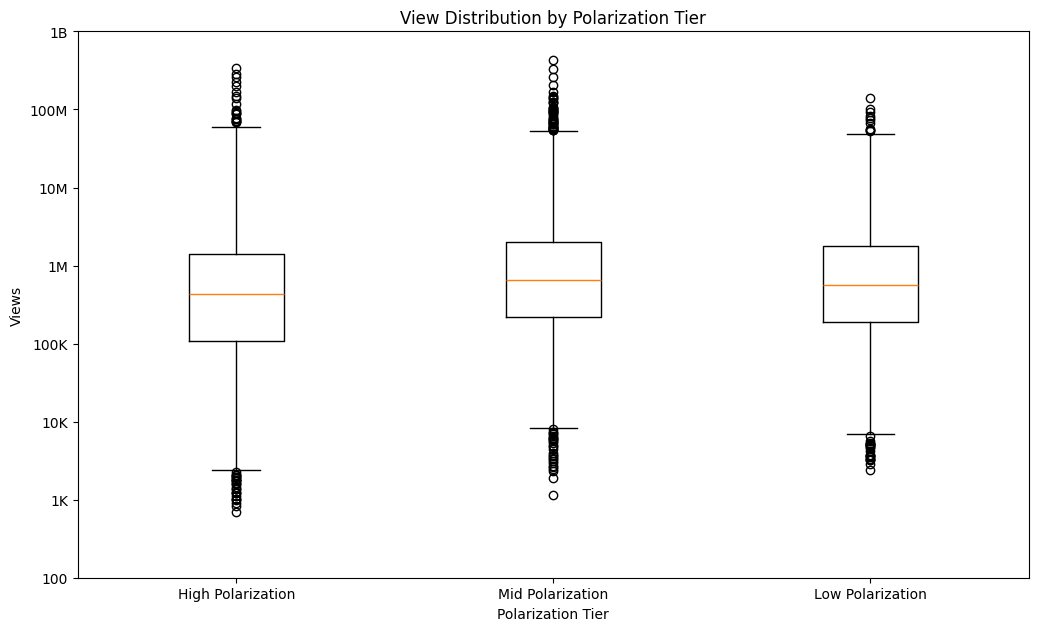

In [73]:
# each tier shares exactly a third of the data
# grouping by tier and median views in log scale
tiers_by_views = all_df_video.groupby('Ratio Tier', observed=True)['views'].apply( # observed True to ignore false values of which are none
    lambda x: np.log10(x)
    .median()
)
print(tiers_by_views)

order = ['High Polarization', 'Mid Polarization', 'Low Polarization']
box_mask = [
    np.log10(all_df_video.loc[all_df_video['Ratio Tier'] == tier, 'views'] + 1)
    for tier in order
    ] # mask for a boxplot of each category in same plot
plt.figure(figsize=(10,6))
plt.boxplot(box_mask, tick_labels=order)
plt.tight_layout()
plt.yticks(
    ticks=[2, 3, 4, 5, 6, 7, 8, 9],
    labels=['100', '1K', '10K', '100K', '1M', '10M', '100M', '1B'] # coverting the yticks back to readable numbers
)
plt.xlabel('Polarization Tier')
plt.ylabel('Views')
plt.title('View Distribution by Polarization Tier')

High Polarization: 10^5.63 ≈ 426k

Mid Polarization: 10^5.81 ≈ 646k

Low Polarization: 10^5.75 ≈ 562k

These are the figures for our 3 quantiles of likes to dislikes ratio. If the client’s hypothesis were correct, the most polarizing tier would exhibit the highest median views. But the highest group is the middle one, Mid Polarization, refuting the client's hypothesis further. Even the boxplots are close to identical.

The analysis shows a strong relationship between views and total engagement metrics including likes, dislikes, and comments, indicating that exposure is more correlative with engagement. However, the like-to-dislike ratio shows only a weak correlation with views (0.10), and highly polarizing videos do not exhibit higher median view counts. Therefore, the data provides little evidence that polarization is a primary driver of engagement. 

One final analysis, I will account for confounding variables like category and likes. Category has not been analyzed yet so next we take a look.

Text(0.5, 1.0, 'Median Likes by Category (log scale)')

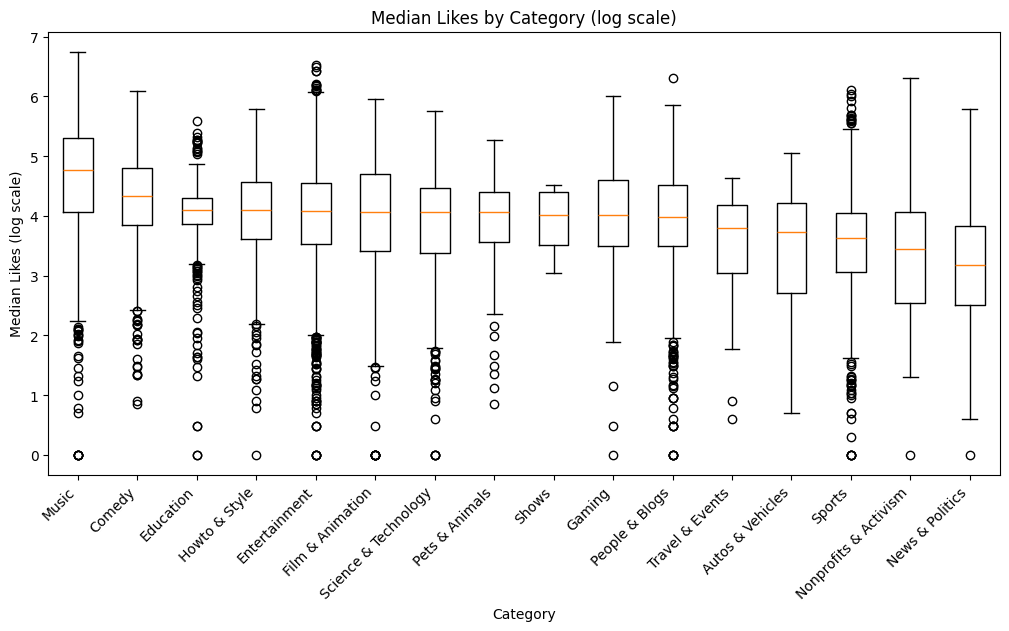

In [74]:
all_df_video['category_name'] = ( #applying category_map to the final dataframe to get new column
    all_df_video['category_id']
    .map(category_map)
)

df = all_df_video.copy() # analysis requires log scale, making copy of df to scale
df['log_likes'] = np.log10(df['likes'] + 1)
# creating new df grouped by category and ordered by median likes
order = df.groupby('category_name', observed=False)['log_likes'].median().sort_values(ascending=False).index
box_mask = [df.loc[df['category_name'] == c, 'log_likes'] for c in order] # mask for a boxplot of each category in same plot
plt.figure(figsize=(10,6))
plt.boxplot(box_mask, tick_labels=order)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.xlabel('Category')
plt.ylabel('Median Likes (log scale)')
plt.title('Median Likes by Category (log scale)')

In [ ]:
# Music dominates in median likes while news and politics are the lowest
# Our polarization theory is not being supported still but more calculations to follow
# summary table of median values by categories
summary = (
    all_df_video
    .groupby('category_name', observed=True)
    .agg(
        median_views=('views', 'median'),
        median_likes=('likes', 'median'),
        median_ratio=('likes_to_dislikes', 'median')
    )
    .sort_values('median_views', ascending=False)
)
print(summary)        

                       median_views  median_likes  median_ratio
category_name                                                  
Music                     1654199.0       59316.0     40.269122
Comedy                     784451.0       21279.0     29.717900
Shows                      765522.0       13675.0     27.975304
Film & Animation           726665.0       11760.0     22.614951
Entertainment              616420.5       12008.5     24.478981
Gaming                     462174.5       10336.5     25.917749
Science & Technology       431057.5       11575.5     26.805310
Pets & Animals             392655.0       11486.0     54.722380
Autos & Vehicles           390383.5        5329.0     18.266479
Sports                     376867.5        4223.5     18.122850
Travel & Events            366169.5        6285.5     26.528845
Education                  356063.0       12576.0     33.153050
Howto & Style              332114.0       12422.0     37.671464
People & Blogs             324428.5     

Music is now more than twice the median views as the next category, Comedy. It also shows a high median ratio meaning much lower "polarization."
Meanwhile, News & Politics is second to last with the lowest median ratio. If we accept our polarization theory, News & Politics should be higher on the list, further disproving our client. This table suggest category type is a strong driver of views and shares.

Next I will model regressions with categories and country as possible confounding variables. To improve the results, I will no longer use the dislike ratio as it is volatile in the highest values. Instead, I will calculate a dislike rate using the total likes and dislikes, binding our value range between 0 and 1.

In [76]:
# log trasnformed views (add 1 to avoid log(0))
df['log_views'] = np.log10(df['views'] + 1)
# log trasnformed likes
df['log_likes'] = np.log10(df['likes'] + 1)
# Create dislike rate (clean polarization metric)
df['dislike_rate'] = df['dislikes'] / (df['likes'] + df['dislikes'] + 1)
model = smf.ols(
    'log_views ~ dislike_rate + C(category_name) + C(country)',
    data=df
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_views   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     76.25
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          3.12e-248
Time:                        14:09:27   Log-Likelihood:                -11120.
No. Observations:                9623   AIC:                         2.228e+04
Df Residuals:                    9605   BIC:                         2.241e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [84]:
# A 1-unit increase in dislike_rate is associated with a 0.38 unit decrease in log_views.
# This suggests negatively received videos are not generating greater reach or views.
# Trying log_likes as a controlled variable
model = smf.ols(
    'log_views ~ dislike_rate + C(category_name) + log_likes',
    data=df
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_views   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     2176.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:49:13   Log-Likelihood:                -4130.2
No. Observations:                9623   AIC:                             8296.
Df Residuals:                    9605   BIC:                             8425.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [78]:
# checking engagement rate against dislike rate
df['log_engagement'] = np.log10(df['engagement_rate'] + 1)
model = smf.ols(
    'log_engagement ~ dislike_rate + C(category_name) + C(country)',
    data=df
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         log_engagement   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     67.62
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          2.54e-220
Time:                        14:09:27   Log-Likelihood:                 29828.
No. Observations:                9623   AIC:                        -5.962e+04
Df Residuals:                    9605   BIC:                        -5.949e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

When controlling for category and country, dislike rate shows a slight negative association with views. When controlling additionally for total likes, that relationship reversed, and R^2 increases to 0.79, suggesting that among similarly popular videos, disagreement does correspond with a slightly higher reach. However, given the direct causal relationship between views and likes, the results should be interpreted cautiously, and likely is a proxy for "how popular is a video among already-seen videos."

After correcting the engagement rate function, R^2 dropped from 0.16 to 0.11, meaning before the metric was inflated by capturing volume rather than density, which is what the column should measure. However, the findings are similar: higher dislike rates are associated with lower engagement having a coefficient of -0.0146. That means more polarization slightly decreases overall engagement which is a direct refutation of the client's theory. 

In conclusion, this analysis examining a few questions including whether highly polarized YouTube videos received greater engagement and reach. After exploratory analysis, quantile comparisons, and regression modeling, the data does not provide strong evidence that polarization drives views.

Key findings include:
- Views are strongly associated with overall engagement metrics including likes and comments.
- The like-to-dislike ratio shows only a weak relationship with views.
- When controlling for category and country, higher dislikes are associated with slightly lower views.
- Additionally when controlling for likes, the relationship reversed. This effect should be interpreted cautiously due to the direct relationship between views and likes, but the implication is that among similarly viewed videos, disagreement does correspond with higher reach.
- Categories explain the most substantial variation in views rather than polarization.

Overall, the evidence suggests that category and likes are stronger predictors of reach than disagreement. While some data implies polarization can generate some views between similarly levels of shared videos, it does not appear to systematically drive higher view counts in this dataset.

It's important to note we are using views as a measurement of "getting shared the most," which is not the most direct. A direct measurement was not provided and future analysis should incorporate true sharing metrics for better analysis.

Category ID, trending date, tags, and even a breakdown of the description columns could also be investigated further. Categories and tags help tell what content is most popular. We could find key words that help uncover viral terms or phrases that help attract view shares or create a sentiment analysis. And while we used publish date as the default datetime measuremnt, trending times can be analyzed for patterns as well, though it would require more dimensional calculations.